# Lab 2: Numpy and Data Representations in Deep Learning

Last week you set up your tools. This week you build the toolkit you will use in every remaining lab: NumPy.

Everything a neural network does, taking a weighted sum, applying a nonlinearity, batching samples together, is a NumPy operation underneath. This lab covers the full set you will need for the rest of the semester, so treat it as a reference you can come back to, not something you need to memorize in one sitting.

## How this lab works

Most sections follow the same pattern: 
- a short explanation
- a `# TODO` cell for you to fill in
- a self-check cell that tells you if you got it right. Run the self-check after every exercise. If it fails, read the assertion message, it tells you what was expected.

## Learning objectives

By the end of this lab, you should be able to:
- Create arrays and inspect their shape, dimensionality, and dtype
- Select subsets of an array with slicing, boolean masks, and fancy indexing
- Combine several arrays into a batch, and pull individual samples back out
- Reshape, flatten, transpose, and add or remove axes, and explain why shapes stop matching when you get this wrong
- Perform elementwise arithmetic and explain how broadcasting extends it to mismatched shapes
- Compute dot products and matrix products, and connect them to what a neural network layer actually does
- Reduce an array along a chosen axis with sum, mean, and argmax
- Explain why vectorized NumPy code is faster than an equivalent Python loop
- Play with real-world data

---
## Setup

Run this once at the top. Setting a random seed makes every random array in this notebook reproducible: you and your classemates will get the exact same numbers, which makes comparing answers possible.

In [1]:
import numpy as np

np.random.seed(0)
print("NumPy version:", np.__version__)

NumPy version: 2.5.3


---
## 1. Array basics and creation

A NumPy array is created from a Python list with `np.array(...)`, or directly with a handful of built-in constructors:

```python
np.zeros(5)          # array of 5 zeros
np.ones((2, 3))       # 2x3 array of ones
np.arange(10)          # 0, 1, ..., 9
np.random.randn(3, 4)   # 3x4 array of random values (standard normal)
```

Every array has three attributes worth checking constantly, especially when something isn't working:
```python
a.shape   # a tuple of dimension sizes, e.g. (3, 4)
a.ndim    # number of dimensions, e.g. 2
a.dtype   # the data type stored, e.g. float64
```

**Exercise 1.1:** create a 1D array of 6 zeros called `zeros6`.

In [ ]:
# TODO: create a 1D array of 6 zeros
zeros6 = ...


In [ ]:
assert zeros6.shape == (6,), f"Expected shape (6,), got {zeros6.shape}"
assert np.all(zeros6 == 0), "Expected all values to be 0"
print("zeros6 is correct!")

**Exercise 1.2:** create a 1D array containing the integers 0 through 9 (inclusive) called `count_up`, using `np.arange`.

In [ ]:
# TODO: create an array of integers 0 through 9
count_up = ...


In [ ]:
expected = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
assert np.array_equal(count_up, expected), f"Expected {expected}, got {count_up}"
print("count_up is correct!")

**Exercise 1.3:** create a 4x3 array of random values called `random_batch`, using `np.random.randn`. Think of this as 4 samples, each with 3 features, the shape you'll see constantly for the rest of the semester.

In [ ]:
# TODO: create a 4x3 array of random values
random_batch = ...


In [ ]:
assert random_batch.shape == (4, 3), f"Expected shape (4, 3), got {random_batch.shape}"
assert random_batch.ndim == 2, f"Expected 2 dimensions, got {random_batch.ndim}"
print("random_batch is correct!")

### Why we set a random seed

Run the cell below twice in a row.

In [ ]:
print(np.random.randn(3))

You should get *different* numbers each time, since nothing is fixing the randomness. Now run the cell below (which re-seeds first) twice in a row.

In [ ]:
np.random.seed(42)
print(np.random.randn(3))

This time you get the *same* numbers both times. Reproducibility matters all semester, for debugging (so a bug you found once will still be there when you look again), and for comparing results (so a change you made, not random luck, explains a different outcome).

---
## 2. Indexing and slicing

Selecting parts of an array works a lot like Python lists, plus a few NumPy-specific tricks.

```python
a[0]        # first element
a[-1]        # last element
a[2:5]        # elements 2, 3, 4 (slice)
a[:3]          # first 3 elements
a[::-1]         # reversed

# for 2D arrays, index each axis, separated by a comma
m[0, :]         # first row
m[:, 1]          # second column
m[1:3, 0:2]       # a sub-block
```

There are two more powerful forms you'll use often:
- **Boolean masking**: `a[a > 0]` returns only the elements where the condition is true.
- **Fancy indexing**: `a[[0, 2, 5]]` returns the elements at those exact positions, in that order.

**Exercise 2.1:** `readings` below holds 10 temperature readings. Select the **last 3** readings into `last_three`, using slicing (not hardcoded indices).

In [ ]:
readings = np.array([12.1, 13.4, 14.0, 15.2, 16.8, 17.1, 16.5, 15.9, 14.3, 13.0])

# TODO: select the last 3 readings using a slice
last_three = ...


In [ ]:
expected = np.array([15.9, 14.3, 13.0])
assert np.array_equal(last_three, expected), f"Expected {expected}, got {last_three}"
print("last_three is correct!")

**Exercise 2.2:** `grades` below is a 4x3 array: 4 students, 3 subjects each. Select **student 2's** row (index 2) into `student_2_grades`, and **subject 1's** column (index 1, all students) into `subject_1_grades`.

In [ ]:
grades = np.array([
    [88, 92, 79],
    [95, 84, 90],
    [70, 65, 72],
    [100, 98, 95],
])

# TODO: select student 2's row (a 1D array of 3 grades)
student_2_grades = ...

# TODO: select subject 1's column (a 1D array of 4 grades)
subject_1_grades = ...


In [ ]:
expected_student = np.array([70, 65, 72])
expected_subject = np.array([92, 84, 65, 98])
assert np.array_equal(student_2_grades, expected_student), f"Expected {expected_student}, got {student_2_grades}"
assert np.array_equal(subject_1_grades, expected_subject), f"Expected {expected_subject}, got {subject_1_grades}"
print("Both selections are correct!")

**Exercise 2.3 (boolean masking):** from `grades` above, select every grade that is **80 or above** into a 1D array called `passing_grades`. You don't need a loop, a single boolean mask does it.

In [ ]:
# TODO: select all grades >= 80 using a boolean mask
passing_grades = ...


In [ ]:
expected = np.array([88, 92, 95, 84, 90, 100, 98, 95])
assert np.array_equal(np.sort(passing_grades), np.sort(expected)), f"Expected values {expected} (any order), got {passing_grades}"
print("passing_grades is correct!")

**Exercise 2.4 (fancy indexing):** `class_labels` below has 8 labels. Select the labels at positions **0, 3, and 7** into `chosen_labels`, in that order, using fancy indexing (a list of indices, not three separate lookups).

In [ ]:
class_labels = np.array(["cat", "dog", "cat", "bird", "dog", "cat", "bird", "dog"])

# TODO: select the labels at positions 0, 3, 7 using fancy indexing
chosen_labels = ...


In [ ]:
expected = np.array(["cat", "bird", "dog"])
assert np.array_equal(chosen_labels, expected), f"Expected {expected}, got {chosen_labels}"
print("chosen_labels is correct!")

---
## 3. Stacking and combining

Indexing pulls pieces out of an array. Stacking does the opposite: it combines several arrays into one. This matters constantly in deep learning, since you almost never process one sample at a time, you gather several into a **batch** first.

```python
np.stack([a, b, c])          # combines 1D arrays into a new 2D array, one row each
np.concatenate([m1, m2], axis=0)  # joins arrays along an existing axis
np.vstack([m1, m2])           # stack row-wise (shorthand for concatenate along axis=0)
np.hstack([m1, m2])            # stack column-wise (axis=1)
```

**Exercise 3.1:** below are three individual samples, each a 1D array of 4 features. Combine them into a single batch array `batch` of shape `(3, 4)`, using `np.stack`.

In [ ]:
sample_a = np.array([1.0, 2.0, 3.0, 4.0])
sample_b = np.array([5.0, 6.0, 7.0, 8.0])
sample_c = np.array([9.0, 10.0, 11.0, 12.0])

# TODO: stack the three samples into one (3, 4) batch array
batch = ...


In [ ]:
assert batch.shape == (3, 4), f"Expected shape (3, 4), got {batch.shape}"
assert np.array_equal(batch[0], sample_a), "Row 0 should be sample_a"
assert np.array_equal(batch[2], sample_c), "Row 2 should be sample_c"
print("batch is correct!")

**Exercise 3.2:** you now receive a second batch, `batch_2`, also with 4 features per sample. Combine `batch` and `batch_2` into one larger batch `full_batch`, using `np.concatenate` along the sample axis.

In [ ]:
batch_2 = np.array([
    [13.0, 14.0, 15.0, 16.0],
    [17.0, 18.0, 19.0, 20.0],
])

# TODO: concatenate batch and batch_2 along the sample axis (axis=0)
full_batch = ...


In [ ]:
assert full_batch.shape == (5, 4), f"Expected shape (5, 4), got {full_batch.shape}"
assert np.array_equal(full_batch[:3], batch), "First 3 rows should match the original batch"
assert np.array_equal(full_batch[3:], batch_2), "Last 2 rows should match batch_2"
print("full_batch is correct!")

---
## 4. Reshape and axis manipulation

Reshaping changes how an array's data is organized into axes, without changing the data itself. This is essential for batching: a single flat vector often needs an extra axis to look like "a batch of 1", and a 2D image often needs flattening to feed into a layer that expects a 1D vector.

```python
a.reshape(2, 3)      # reorganize into a 2x3 array (must have the same total size)
a.reshape(-1)          # flatten to 1D (the -1 means "figure out this size")
a.flatten()              # same idea, always returns a copy
a.T                        # transpose: swap axes (rows become columns)
a[np.newaxis, :]            # insert a new axis of size 1 at the front
np.expand_dims(a, axis=0)    # same idea, more explicit
a.squeeze()                    # remove all axes of size 1
```

**Exercise 4.1:** `flat_image` below is a flattened 12-pixel image (pretend it's a tiny 3x4 image). Reshape it into a `(3, 4)` array called `image`.

In [ ]:
flat_image = np.arange(12)

# TODO: reshape flat_image into a (3, 4) array
image = ...


In [ ]:
assert image.shape == (3, 4), f"Expected shape (3, 4), got {image.shape}"
assert np.array_equal(image.reshape(-1), flat_image), "Reshaping back to 1D should recover flat_image"
print("image is correct!")

**Exercise 4.2:** now flatten `image` back into a 1D array called `flattened_again`, using `.reshape(-1)` or `.flatten()`.

In [ ]:
# TODO: flatten image back to 1D
flattened_again = ...


In [ ]:
assert flattened_again.shape == (12,), f"Expected shape (12,), got {flattened_again.shape}"
assert np.array_equal(flattened_again, flat_image), f"Expected {flat_image}, got {flattened_again}"
print("flattened_again is correct!")

**Exercise 4.3:** `single_sample` below has shape `(4,)`, a single sample with 4 features. A lot of code you'll write later expects a *batch*, even a batch of one. Turn it into `sample_as_batch` with shape `(1, 4)`, using `np.newaxis` (or `reshape`).

In [ ]:
single_sample = np.array([1.0, 2.0, 3.0, 4.0])

# TODO: add a batch axis so the shape becomes (1, 4)
sample_as_batch = ...


In [ ]:
assert sample_as_batch.shape == (1, 4), f"Expected shape (1, 4), got {sample_as_batch.shape}"
assert np.array_equal(sample_as_batch[0], single_sample), "The single row should match single_sample"
print("sample_as_batch is correct!")

### When shapes silently do the wrong thing

Run the cell below.

In [ ]:
weights = np.array([0.5, -0.2, 0.1, 0.9])   # shape (4,)
one_weight_per_sample = np.array([1.0, 2.0, 3.0])  # shape (3,), one scalar per sample, unrelated to weights

# this is intentionally wrong: mixing up two differently-shaped 1D arrays
try:
    result = weights + one_weight_per_sample
    print("Result:", result)
except ValueError as e:
    print("Error:", e)

That failed with a shape mismatch, which is the *good* outcome: NumPy told you immediately. The more dangerous case is when shapes are compatible by accident but mean different things, no error, just a wrong answer that silently propagates through your whole notebook.

**Exercise 4.4:** `per_sample_score` below has shape `(3,)`, one score per sample. You want to add it to `sample_scores`, a `(3, 1)` per-sample column, so that each sample's score is boosted. Reshape `per_sample_score` to `(3, 1)` (so its shape matches what it conceptually represents) and store it as `per_sample_score_col`, then compute `boosted` as the elementwise sum.

In [ ]:
sample_scores = np.array([[10.0], [20.0], [30.0]])   # shape (3, 1)
per_sample_score = np.array([1.0, 2.0, 3.0])            # shape (3,)

# TODO: reshape per_sample_score to (3, 1)
per_sample_score_col = ...

# TODO: add sample_scores and per_sample_score_col elementwise
boosted = ...


In [ ]:
assert per_sample_score_col.shape == (3, 1), f"Expected shape (3, 1), got {per_sample_score_col.shape}"
expected = np.array([[11.0], [22.0], [33.0]])
assert np.array_equal(boosted, expected), f"Expected {expected.tolist()}, got {boosted.tolist()}"
print("boosted is correct!")

One more tool worth knowing here: **transpose**. `a.T` swaps an array's axes, most often used to flip between "rows are samples" and "rows are something else" (you'll see this constantly with weight matrices in a few weeks).

In [ ]:
m = np.arange(6).reshape(2, 3)
print("m, shape", m.shape)
print(m)
print()
print("m.T, shape", m.T.shape)
print(m.T)

---
## 5. Elementwise operations, arithmetic, and broadcasting

### Basic arithmetic

Arithmetic on NumPy arrays happens elementwise, position by position, with no loop needed.

```python
a + b     # elementwise sum
a - b      # elementwise difference
a * b       # elementwise product (NOT matrix multiplication, more on that in section 6)
a * 2         # multiply every element by a scalar
```

**Exercise 5.1:** given `v1` and `v2` below (same shape), compute their elementwise sum as `v_sum` and their elementwise product as `v_prod`.

In [ ]:
v1 = np.array([1.0, 2.0, 3.0, 4.0])
v2 = np.array([10.0, 20.0, 30.0, 40.0])

# TODO: elementwise sum
v_sum = ...

# TODO: elementwise product
v_prod = ...


In [ ]:
expected_sum = np.array([11.0, 22.0, 33.0, 44.0])
expected_prod = np.array([10.0, 40.0, 90.0, 160.0])
assert np.array_equal(v_sum, expected_sum), f"Expected {expected_sum}, got {v_sum}"
assert np.array_equal(v_prod, expected_prod), f"Expected {expected_prod}, got {v_prod}"
print("v_sum and v_prod are correct!")

**Exercise 5.2:** `pixels` below holds raw pixel values from 0 to 255. Normalize them to the 0 to 1 range by multiplying by the right scalar, storing the result as `normalized_pixels`. This exact operation is the first thing you'll do to every image in Lab 3.

In [ ]:
pixels = np.array([0, 64, 128, 192, 255])

# TODO: scale pixels to the range [0, 1]
normalized_pixels = ...


In [ ]:
expected = np.array([0.0, 64/255, 128/255, 192/255, 1.0])
assert np.allclose(normalized_pixels, expected), f"Expected {expected}, got {normalized_pixels}"
print("normalized_pixels is correct!")

### Universal functions

NumPy applies functions like `np.exp`, `np.log`, and `np.maximum` elementwise too, no loop needed.

**Exercise 5.3:** implement `relu(x)`, which returns `x` where `x` is positive and `0` everywhere else. Use `np.maximum`, this one line *is* the ReLU activation function you'll see again and again starting in Lab 6.

In [ ]:
def relu(x):
    # TODO: return the elementwise maximum of x and 0
    ...


test_input = np.array([-3.0, -1.0, 0.0, 2.0, 5.0])
print(relu(test_input))

In [ ]:
expected = np.array([0.0, 0.0, 0.0, 2.0, 5.0])
assert np.array_equal(relu(test_input), expected), f"Expected {expected}, got {relu(test_input)}"
print("relu is correct!")

**Exercise 5.4:** implement `sigmoid(x)`, defined as `1 / (1 + exp(-x))`. Use `np.exp`.

In [ ]:
def sigmoid(x):
    # TODO: return 1 / (1 + exp(-x))
    ...


print(sigmoid(np.array([-10.0, 0.0, 10.0])))

In [ ]:
result = sigmoid(np.array([-10.0, 0.0, 10.0]))
expected = np.array([4.5397868702e-05, 0.5, 0.9999546021])
assert np.allclose(result, expected, atol=1e-6), f"Expected approximately {expected}, got {result}"
print("sigmoid is correct!")

### Broadcasting

Arithmetic between two *identically shaped* arrays is straightforward, position matches position. Broadcasting is the rule NumPy uses to make arithmetic work between arrays of *different* shapes, by conceptually stretching the smaller one to match, without actually copying data.

The rule that matters most in practice: comparing shapes from right to left, dimensions must either match, or one of them must be `1`. For example, a `(4, 3)` array and a `(3,)` array broadcast together, since the trailing `3` matches. A `(4, 3)` array and a `(4,)` array do **not** broadcast directly, the trailing dimensions are `3` and `4`, neither matches nor is `1`.

**Exercise 5.5:** `samples` below has shape `(4, 3)`: 4 samples, 3 features. `feature_means` has shape `(3,)`, the mean of each feature. Center the data by subtracting `feature_means` from every row of `samples`, storing the result as `centered`. You don't need a loop, broadcasting does it in one line.

In [ ]:
samples = np.array([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0],
])
feature_means = np.array([2.5, 25.0, 250.0])

# TODO: subtract feature_means from every row of samples
centered = ...


In [ ]:
expected = samples - feature_means
assert np.array_equal(centered, expected), f"Expected {expected.tolist()}, got {centered.tolist()}"
assert np.allclose(centered.mean(axis=0), 0.0), "Each feature's mean should now be 0"
print("centered is correct!")

Now the trap. Run the cell below.

In [ ]:
sample_means = samples.mean(axis=1)  # shape (4,): one mean per SAMPLE, not per feature
print("sample_means shape:", sample_means.shape)

try:
    wrong = samples - sample_means
    print(wrong)
except ValueError as e:
    print("Error:", e)

That raises an error, `(4, 3)` and `(4,)` don't broadcast, since the trailing dimensions are `3` and `4`. NumPy caught this one for you. But it would **not** catch it if `sample_means` happened to also have length 3 by coincidence, wrong values, no error, no warning. The only real defense is checking shapes deliberately, which is exactly what `.shape` is for.

**Exercise 5.6:** fix the trap above. You want to subtract each sample's own mean from that sample's 3 feature values (so every sample ends up centered around 0 individually). Reshape `sample_means` to `(4, 1)` as `sample_means_col`, then compute `centered_per_sample` as `samples - sample_means_col`.

In [ ]:
# TODO: reshape sample_means to (4, 1)
sample_means_col = ...

# TODO: subtract sample_means_col from samples
centered_per_sample = ...


In [ ]:
assert sample_means_col.shape == (4, 1), f"Expected shape (4, 1), got {sample_means_col.shape}"
assert np.allclose(centered_per_sample.mean(axis=1), 0.0), "Each sample's mean should now be 0"
print("centered_per_sample is correct!")

---
## 6. Matrix operations

This section is the one that matters most for the rest of the semester. A dot product, a matrix-vector product, and a batched matrix-matrix product are, respectively, one neuron, one layer, and one layer applied to a whole batch. Every `Linear` layer you build starting in Lab 4 is built on exactly this.

### Dot product: one neuron

The dot product of two vectors multiplies them elementwise, then sums the result, a **weighted sum**.

```python
np.dot(x, w)    # or equivalently: x @ w
```

**Exercise 6.1:** `features` and `weights` below both have shape `(4,)`. Compute their dot product as `weighted_sum`, using `np.dot` or `@`. Compare it to the manual elementwise-multiply-then-sum version to confirm they're the same operation.

In [ ]:
features = np.array([1.0, 2.0, 3.0, 4.0])
weights = np.array([0.5, -0.2, 0.1, 0.9])

# TODO: compute the dot product of features and weights
weighted_sum = ...

manual_version = np.sum(features * weights)
print("dot product:", weighted_sum)
print("manual elementwise-multiply-then-sum:", manual_version)

In [ ]:
expected = float(np.sum(features * weights))
assert np.isclose(weighted_sum, expected), f"Expected {expected}, got {weighted_sum}"
print("weighted_sum is correct, and matches the manual version!")

### Matrix-vector product: one layer, many neurons at once

A weight *matrix* stacks several neurons' weight vectors into one array, one row per neuron. Multiplying that matrix by an input vector computes every neuron's weighted sum in a single operation.

**Exercise 6.2:** `W` below has shape `(3, 4)`, 3 neurons, each with 4 weights (matching `features` above, which has 4 elements). Compute `layer_output`, the output of all 3 neurons at once, as `W @ features`. The result should have shape `(3,)`.

In [ ]:
W = np.array([
    [0.5, -0.2, 0.1, 0.9],
    [0.1, 0.1, 0.1, 0.1],
    [-1.0, 0.5, 0.5, 0.0],
])

# TODO: compute all 3 neurons' outputs at once
layer_output = ...


In [ ]:
expected = W @ features
assert layer_output.shape == (3,), f"Expected shape (3,), got {layer_output.shape}"
assert np.allclose(layer_output, expected), f"Expected {expected}, got {layer_output}"
assert np.isclose(layer_output[0], weighted_sum), "Neuron 0's output should match weighted_sum from exercise 6.1, since W's first row is the same as weights"
print("layer_output is correct!")

### Batched matrix-matrix product: one layer, many samples, many neurons, all at once

Instead of one input vector, you'll usually have a whole *batch* of inputs, shape `(num_samples, num_features)`. Multiplying the batch by the transposed weight matrix computes every neuron's output, for every sample, in one operation. This is the actual forward pass of a `Linear` layer.

**Exercise 6.3:** `X` below has shape `(5, 4)`, 5 samples, 4 features each (matching `W` above, which expects 4 features per neuron). Compute `batch_output`, every neuron's output for every sample, as `X @ W.T`. The result should have shape `(5, 3)`, 5 samples, 3 neuron outputs each.

In [ ]:
X = np.array([
    [1.0, 2.0, 3.0, 4.0],
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 1.0, 1.0],
    [-1.0, -2.0, -3.0, -4.0],
    [2.0, 0.0, -2.0, 0.0],
])

# TODO: compute every neuron's output for every sample at once
batch_output = ...


In [ ]:
expected = X @ W.T
assert batch_output.shape == (5, 3), f"Expected shape (5, 3), got {batch_output.shape}"
assert np.allclose(batch_output, expected), f"Expected {expected.tolist()}, got {batch_output.tolist()}"
assert np.allclose(batch_output[0], layer_output), "Row 0 should match layer_output from exercise 6.2, since X's first row is the same as features"
print("batch_output is correct! This is exactly what a Linear layer computes.")

---
## 7. Reductions

A reduction collapses an array along one axis into a single summary value per remaining position: a sum, a mean, a max. The `axis` argument controls which direction collapses.

```python
a.sum()             # sum of everything, returns a scalar
a.sum(axis=0)         # sum down each column, collapses axis 0
a.sum(axis=1)           # sum across each row, collapses axis 1
a.mean(axis=...)          # same idea, for the mean
a.std(axis=...)            # same idea, for the standard deviation
a.max(axis=...), a.min(axis=...)   # same idea, for max/min
a.argmax(axis=...)                   # INDEX of the max, not the value itself
```

`axis=0` collapses rows (you get one result per column), `axis=1` collapses columns (you get one result per row). This trips almost everyone up at least once, when in doubt, check the output shape.

**Exercise 7.1:** using `batch_output` from exercise 6.3 (shape `(5, 3)`), compute the sum of each sample's 3 neuron outputs, as `per_sample_sum`. The result should have shape `(5,)`, one value per sample.

In [ ]:
# TODO: sum each sample's neuron outputs (collapse axis 1)
per_sample_sum = ...


In [ ]:
expected = batch_output.sum(axis=1)
assert per_sample_sum.shape == (5,), f"Expected shape (5,), got {per_sample_sum.shape}"
assert np.allclose(per_sample_sum, expected), f"Expected {expected}, got {per_sample_sum}"
print("per_sample_sum is correct!")

**Exercise 7.2:** now compute the mean of each neuron's output *across all 5 samples*, as `per_neuron_mean`. The result should have shape `(3,)`, one value per neuron. This is the same "collapse the sample axis" operation you used to center features in exercise 5.5, from the other direction.

In [ ]:
# TODO: compute the mean of each neuron's output across all samples (collapse axis 0)
per_neuron_mean = ...


In [ ]:
expected = batch_output.mean(axis=0)
assert per_neuron_mean.shape == (3,), f"Expected shape (3,), got {per_neuron_mean.shape}"
assert np.allclose(per_neuron_mean, expected), f"Expected {expected}, got {per_neuron_mean}"
print("per_neuron_mean is correct!")

**Exercise 7.3:** `class_scores` below holds 4 samples' scores across 3 classes, shape `(4, 3)`. For each sample, find the **index** of the class with the highest score (the model's predicted class), as `predictions`, using `argmax` with the right axis. The result should have shape `(4,)`.

In [ ]:
class_scores = np.array([
    [0.1, 0.7, 0.2],
    [0.8, 0.1, 0.1],
    [0.2, 0.3, 0.5],
    [0.05, 0.05, 0.9],
])

# TODO: find the predicted class (index of max score) for each sample
predictions = ...


In [ ]:
expected = np.array([1, 0, 2, 2])
assert predictions.shape == (4,), f"Expected shape (4,), got {predictions.shape}"
assert np.array_equal(predictions, expected), f"Expected {expected}, got {predictions}"
print("predictions is correct! This is exactly how you'll read a model's predicted class starting in Lab 9.")

---
## 8. Why vectorize

Everything above could technically be written with Python `for` loops instead. Let's see why nobody does that in practice.

Run both cells below and compare the timings.

In [2]:
big_a = np.random.randn(1_000_000)
big_b = np.random.randn(1_000_000)

def loop_dot(a, b):
    total = 0.0
    for i in range(len(a)):
        total += a[i] * b[i]
    return total

%timeit loop_dot(big_a, big_b)

342 ms ± 17.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [3]:
%timeit np.dot(big_a, big_b)

648 μs ± 18.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


The vectorized version should be somewhere between 50 and 200 times faster, and that gap only grows as arrays get bigger. NumPy's loop happens in compiled C code instead of interpreted Python, and it's why every operation in this lab, and every layer you build for the rest of the semester, is written without explicit Python loops over array elements. If you ever find yourself writing `for i in range(...)` to process an array, it's worth pausing to ask whether a vectorized version exists instead.

---
## 9. Representing image

For remaining excercise, you will need to install the `dataset` and `librosa` Python packages. Steps:
- Activate your `conda` environment in the terminal
- Run `pip install datasets librosa`

/home/cwang/miniconda3/envs/teach/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of general Paris photots: 543


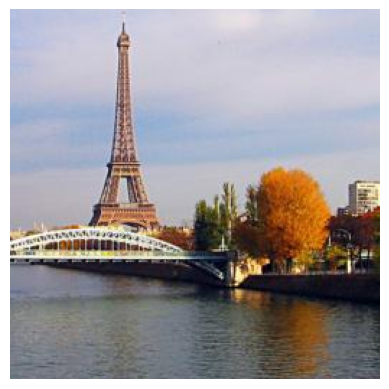

In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset(
    "JamieSJS/r-paris-hard",
    "corpus",
    split="corpus"
)

paris_general = [item for item in dataset if "general" in item["id"]]
print(f"Number of general Paris photots: {len(paris_general)}")

# Play with other examples by changing `160` to other numbers within the total number of examples
example = paris_general[160]

image_array = np.array(example["image"])
plt.imshow(image_array);
plt.axis("off");

In [ ]:
# TODO: Play with the tensor operations in the previous sections for the image representation
# Slicing

# Reshaping

# Broadcasting

# and the other operations

---
## 10. Representing audio (Optional)

In [2]:
import librosa # for loading and displaying audio
from IPython.display import Audio # for playing audio
from IPython.display import HTML  # for displaying metadata about audio examples

In [3]:
filename = librosa.example("trumpet")
y, sr = librosa.load(filename)

# print out some information about this example
HTML(librosa.util.example_info("trumpet", html=True))

In [4]:
print("number of samples: ", y.shape)
print("duration (s): ", y.shape[0] / sr)
print("time (s) at sample 100: ", librosa.samples_to_time(100, sr=sr))

number of samples:  (117601,)
duration (s):  5.333378684807256
time (s) at sample 100:  0.0045351473922902496


In [5]:
Audio(data=y, rate=sr)

[Text(0.5, 1.0, 'Time-domain')]

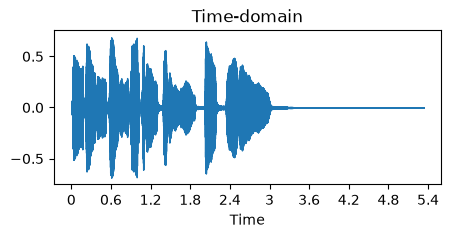

In [6]:
fig, ax = plt.subplots(nrows=1, sharex=True, figsize=(5,2))
stft = librosa.stft(y)
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set(title="Time-domain")

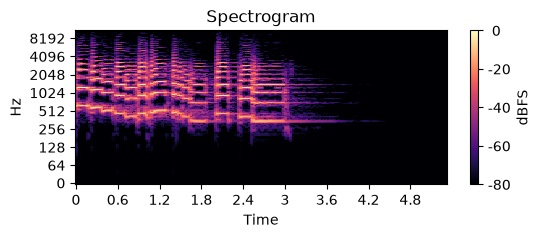

In [7]:
fig, ax = plt.subplots(nrows=1, sharex=True, figsize=(6,2))
stft = librosa.stft(y)
img = librosa.display.specshow(stft, vscale="dBFS",
                               sr=sr, hop_length=512, x_axis="time", y_axis="log", ax=ax)
librosa.display.colorbar_db(img, label="dBFS")
ax.set(title="Spectrogram")
ax.label_outer()

In [ ]:
# TODO: Play with other examples with the names listed in the first column
librosa.util.list_examples()

AVAILABLE EXAMPLES
--------------------------------------------------------------------
brahms    	Brahms - Hungarian Dance #5
choice    	Admiral Bob - Choice (drum+bass)
drese     	Multi-track recording of five instruments playing in unison
drese2    	Alternate recording of "drese" example on trumpet with tempo variation
fishin    	Karissa Hobbs - Let's Go Fishin'
humpback  	Glacier Bay 60-second clip humpback whale song November 2020
libri1    	The Ashiel Mystery: A Detective Story, chapter XVI. / Read by Garth Comira
libri2    	The Age of Chivalry, chapter IX: The Adventure of the Cart / Read by Anders Lankford
libri3    	Sense and Sensibility / Chapter 18 / Jane Austen / Read by Heather Barnett
nutcracker	Tchaikovsky - Dance of the Sugar Plum Fairy
pistachio 	The Piano Lady - Pistachio Ice Cream Ragtime
robin     	Bird Whistling, Robin, Single, 13.wav / InspectorJ
snare     	An accelerating beat on a snare drum
sweetwaltz	Setuniman - Sweet Waltz
trumpet   	Mihai Sorohan - Trumpet l

In [ ]:
# TODO: Play with the tensor operations in the previous sections for the audio representation
# Slicing

# Reshaping

# Broadcasting

# and the other operations

---
## Wrap-up

You now have the NumPy toolkit the rest of the semester is built on: creating and inspecting arrays, indexing and stacking them, reshaping between flat and batched forms, elementwise arithmetic and broadcasting, matrix products as the core of a neural network layer, and reductions for summarizing a batch or reading off a prediction. You have also known how to represent different types of data. Keep this notebook around, you will want to look things up from it constantly over the next few weeks.